**NOMBRES:**
- Diana Silva
- Valentina Giraldo

# Determinantes de la deserción temprana en la facultad de Negocios y Economía (FNE) en la Universidad Icesi

## 1. Contexto del análisis

La Facultad de Negocios y Economía (FNE) de la Universidad Icesi ha identificado la deserción temprana como un reto prioritario, entendida como el retiro de los estudiantes durante los primeros cuatro semestres. Según el Ministerio de Educación Nacional (MEN, 2009), la mayor proporción de deserción en la educación superior colombiana ocurre en los primeros períodos académicos, debido a las dificultades que enfrentan los estudiantes en su adaptación al entorno universitario, la gestión de factores académicos, socioeconómicos y personales.

Comprender estos factores resulta esencial para anticipar riesgos, fortalecer los indicadores de retención y optimizar la planificación académica y financiera. Asimismo, permite a áreas como bienestar universitario, planeación y dirección del programa diseñar estrategias preventivas que mejoren la permanencia y reduzcan los efectos negativos en la continuidad académica y la calidad formativa.



In [2]:
# ===============================
# Importación de librerías
# ===============================

# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Utilidades varias
from unidecode import unidecode

# Scikit-learn: preparación de datos y modelado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Scikit-learn: modelos
from sklearn.linear_model import LogisticRegression

# Scikit-learn: métricas de evaluación
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score
)

In [3]:
df = pd.read_excel(r'base_anonimizada.xlsx')

In [4]:
df.head()

,CANT_SEMESTRE_CURSADOS_NOTA,CANT_SEMESTRE_CURSADOS_TOTAL,CIUDAD_COLEGIO,CATEGORIA_COLEGIO,CIUDAD_DOCUMENTO,COD_CIU_EXPEDICION,COD_PROGRAMA,ES_PILO,ESTADO_PREGRADO,EVENTO_GRADO,...,PROGRAMA_ALTERNO,COD_PROGRAMA_1,PROGRAMA_INICIAL,PUESTO_ICFES,PUNTAJE_ICFES,SEXO_2,TIPO_PROGRAMA,ESTRATO,NATURALEZA_COLEGIO,id_artificial
0,5,5,CALI,MS,Cali,76001,MED,N,Normal,-,...,-,MED,MED - Medicina,-,358,F,Principal,5.0,NO,6349569350048378880
1,4,4,CALI,MS,Cali,76001,MUS,N,Normal,-,...,-,MUS,MUS - Música,-,329,F,Principal,4.0,NO,8697600157497738240
2,4,4,CALI,MS,Cali,76001,DMI,N,Normal,-,...,-,DMI,DMI - Diseño De Medios Interactivos,-,300,F,Principal,4.0,NO,4432690026243963904
3,2,2,CALI,MS,Cali,76001,MIP,N,Normal,-,...,-,MIP,DER - Derecho,-,254,F,Principal,5.0,NO,540403199967644480
4,2,2,CALI,MS,Cali,76001,MIP,N,Normal,-,...,-,MIP,DER - Derecho,-,254,F,Principal,5.0,NO,540403199967644480


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57698 entries, 0 to 57697
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   CANT_SEMESTRE_CURSADOS_NOTA   57698 non-null  int64  
 1   CANT_SEMESTRE_CURSADOS_TOTAL  57698 non-null  int64  
 2   CIUDAD_COLEGIO                57698 non-null  object 
 3   CATEGORIA_COLEGIO             57698 non-null  object 
 4   CIUDAD_DOCUMENTO              57697 non-null  object 
 5   COD_CIU_EXPEDICION            57698 non-null  object 
 6   COD_PROGRAMA                  57698 non-null  object 
 7   ES_PILO                       57698 non-null  object 
 8   ESTADO_PREGRADO               57698 non-null  object 
 9   EVENTO_GRADO                  57698 non-null  object 
 10  EVENTO_RETIRO                 57698 non-null  object 
 11  FECHA_GRADO                   57698 non-null  object 
 12  FECHA_ICFES                   57698 non-null  object 
 13  F

In [6]:
df["PROGRAMA"].value_counts()

PROGRAMA
ADD - Administración De Empresas Plan Diurno                       9503
ENI - Economía Y Negocios Internacionales                          6702
ADN - Administración De Empresas Plan Nocturno                     6339
SIS - Ingeniería De Sistemas                                       4839
MIP - Mercadeo Internacional Y Publicidad                          4364
IND - Ingeniería Industrial                                        3850
DER - Derecho                                                      2505
MED - Medicina                                                     2503
QUF - Química Farmacéutica                                         2027
DIS - Diseño Industrial                                            1774
DMI - Diseño De Medios Interactivos                                1665
TEL - Ingeniería Telemática                                        1431
PSI - Psicología                                                   1380
CIP - Ciencia Política                                 

## 2. Pregunta SMART:
La pregunta de negocio que guiará nuestro análisis será la siguiente: ¿Cuáles son los factores que más influyen en la deserción temprana (semestres 1 a 4) de los estudiantes de la facultad de Negocios y Economía de la Universidad Icesi?

## 3. Diccionario de variables

| Variable                      | Tipo                   | Contexto                                                                                                   | Expectativa                                                                                 |
|-------------------------------|------------------------|------------------------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------|
| id_artificial                 | Cualitativa nominal    | Corresponde al id asignado al estudiante, nace a partir del código de Banner. Se creó un Id artificial para anonimizar la base. | Identificación del estudiante y llave primaria para conectar con otras bases.               |
| PUNTAJE_ICFES                 | Cuantitativa continua  | Puntaje global del estudiante en las pruebas Saber 11. Rango permitido desde 0 a 500.                                                    | Principal proxy del rendimiento académico.                                                  |
| PUESTO_ICFES                  | Cuantitativa discreta  | Puesto ocupado en las pruebas Saber 11.                                                                    | Proxy del rendimiento académico.                                                            |
| SEXO                          | Cualitativa nominal    | Género con el que se identificó el estudiante al ingresar a la Universidad.                                | Permite análisis diferenciados y focalización de estrategias.                               |
| CIUDAD_COLEGIO                | Cualitativa nominal    | Ciudad del colegio en el que el estudiante finalizó su educación media.                                    | Proxy del rendimiento académico según calidad educativa por ciudad.                         |
| FECHA_NACIMIENTO              | Cualitativa nominal    | Fecha de nacimiento del estudiante.                                                                        | Permite calcular la edad del estudiante.                                                    |
| ESTRATO                       | Cualitativa ordinal    | Estrato socioeconómico registrado en el recibo de servicios públicos.                                      | Principal proxy de las condiciones socioeconómicas.                                         |
| CANT_SEMESTRES_CURSADOS_NOTA  | Cuantitativa discreta  | Número de semestres cursados con nota por el estudiante.                                                   | Útil para detectar anomalías y limpieza de la base.                                         |
| ES_PILO                       | Cualitativa nominal    | Define si el estudiante es beneficiario de la Beca Ser Pilo Paga.                                          | Proxy de condiciones socioeconómicas y relacionamiento.                                     |
| ESTADO_PREGRADO               | Cualitativa nominal    | Estado del estudiante en pregrado (retirado, graduado, normal, etc.).                                      | Ayuda a detectar anomalías y análisis exploratorio.                                         |
| EVENTO_RETIRO                 | Cualitativa nominal    | Evento de retiro del estudiante (por bajo rendimiento, otras causas, etc.).                                | Útil para limpieza y análisis exploratorio.                                                 |
| NATURALEZA_COLEGIO            | Cualitativa nominal    | Si el colegio del estudiante es oficial o privado.                                                         | Proxy del rendimiento académico según calidad del colegio.                                  |
| PERIODO_INGRESO_ESTUDIANTE    | Cualitativa nominal    | Periodo de ingreso del estudiante a la Universidad.                                                        | Útil para limpieza y análisis exploratorio.                                                 |
| PERIODO_INGRESO_PROGRAMA      | Cualitativa nominal    | Periodo de ingreso del estudiante al programa.                                                             | Útil para limpieza y análisis exploratorio.                                                 |
| PROGRAMA                      | Cualitativa nominal    | Programa al que ingresó el estudiante.                                                                     | Útil para limpieza y análisis exploratorio.                                                 |
| PROGRAMA_ACTUAL               | Cualitativa nominal    | Programa actual en el que está matriculado el estudiante. Se diferencia de “PROGRAMA” porque puede haber pasado por varios programas. | Útil para limpieza y análisis exploratorio.                                                 |


##  4. Preprocesamiento de la base

La base que se trabajará requerirá de un preprocesamiento, adicional al de la detección y limpieza de anomalías. En la base se pueden encontrar varios estados para los estudiantes de pregrado:

- **Normal:** estudiantes sin alguna novedad en su estado.
- **Retirado:** estudiantes que se retiraron de algún programa.
- **Graduado/Terminado:** estudiantes que finalizaron un programa y se graduaron efectivamente.
- **Prueba:** estudiantes que están en prueba académica.
- **Intercambio entrante:** estudiantes que se encuentran en intercambio en la Universidad.
- **Candidato a Grado:** estudiantes que son candidatos a grado.

La base presenta todos los estados de un estudiante de pregrado, entonces, en ella se pueden encontrar tantos estudiantes como estados hayan tenido durante su paso por la Universidad. Por ejemplo, un estudiante puede haber entrado al programa de Economía y haberse retirado de éste, pero posteriormente se matriculó en el programa de Administración, que ahora se encuentra cursando. En el caso de ese estudiante, aparecerá dos veces en la base, una vez con el estado "Retirado" para el programa de Economía, y una segunda vez con el estado "Normal" para el programa de Adminitración. Esto, indica **la presencia de duplicados**. Dado que la base se filtrará solo por los estudiantes de la Facultad de Negocios y Economía (FNE), los duplicados que se hallen en esta base se deberán duplicar, ya que, el objetivo de este estudio es hallar los determinantes de la deserción temprana **a nivel de la facultad de Negocios (FNE)**. Esto quiere decir que la población objetivo son **aquellos estudiantes que se retiraron de forma temprana (antes de iniciar el 5to semestre) a nivel de la facultad, no del programa**. En el caso del estudiante expuesto con anterioridad, aquel estudiante, a nivel de la facultad, no se encuentra retirado, pues está cursando actualmente un programa de la facultad. Su retiro se encuentra a nivel de programa (se retiró del programa de Economía).

Adicionalmente, de la base se deben sacar todos los estudiantes que vienen a la Universidad por intercambio, pues éstos afectan naturalmente el cálculo de la deserción.

Para poder lograr dejar la base correctamente con todo lo expuesto con anterioridad es necesario llevar las tareas de preprocesamiento que se ejecutarán en esta sección.

El primer paso es identificar los programas de la FNE

In [7]:
PROGRAMAS_NEGOCIOS = [
    "ADD - Administración De Empresas Plan Diurno",
    "ADN - Administración De Empresas Plan Nocturno",
    "COF - Contaduría Pública Y Finanzas Internacionales",
    "ECO - Economía",
    "ENI - Economía Y Negocios Internacionales",
    "FIN - Finanzas",
    "MIP - Mercadeo Internacional Y Publicidad",
]

Luego se filtra la base por estos programas

In [8]:
df_FNE = df[df["PROGRAMA"].isin(PROGRAMAS_NEGOCIOS)].copy()
df_FNE["PROGRAMA"].value_counts()

PROGRAMA
ADD - Administración De Empresas Plan Diurno           9503
ENI - Economía Y Negocios Internacionales              6702
ADN - Administración De Empresas Plan Nocturno         6339
MIP - Mercadeo Internacional Y Publicidad              4364
COF - Contaduría Pública Y Finanzas Internacionales    1212
ECO - Economía                                          516
FIN - Finanzas                                          410
Name: count, dtype: int64

Posteriormente se excluyen del dataset personas con intercambio.

In [9]:
# 1. Filtrar a las personas sin intercambio
df_FNE = df_FNE[df_FNE["INTERCAMBIO"].isin(["N"])].reset_index(drop=True)

Se filtran los períodos posteriores a 2014-2
, debido a que en ese año se modificó la metodología de evaluación de las pruebas Saber 11. De esta manera, se asegura que los puntajes del Icfes analizados hayan sido calificados bajo los mismos criterios de evaluación.

In [10]:
df_FNE["PERIODO_INGRESO_ESTUDIANTE"] = pd.to_numeric(df_FNE["PERIODO_INGRESO_ESTUDIANTE"], errors="coerce")

# Filtrar los periodos >= 201410
df_FNE = df_FNE[df_FNE["PERIODO_INGRESO_ESTUDIANTE"] >= 201420].reset_index(drop=True)

Si en estado de pregrado aparece retirado entonces se considera retirado, si no, entonces no retirado

In [11]:

df_FNE["RETIRO"] = np.where(df_FNE["ESTADO_PREGRADO"] == "Retirado", "Sí", "No")
df_FNE["RETIRO"].value_counts()

RETIRO
No    4756
Sí    1935
Name: count, dtype: int64

El siguiente paso es construir la base de deserción temprana. Esta base resulta de la unión de dos subconjuntos de la base maestra:

- Individuos retirados que al momento de actualización de la base cursaban 1,2,3 o 4 semestres.
- Individuos no retirados que al momento de actualización de la base cursaban 1,2,3 o 4 semestres o individuos que se retiraron despues del 4 semestre.

En los pasos siguientes se genera cada subconjunto y se concatenan.

In [12]:
# Reemplazar "-" por NaN
df_FNE["CANT_SEMESTRE_CURSADOS_NOTA"] = pd.to_numeric(df_FNE["CANT_SEMESTRE_CURSADOS_NOTA"], errors="coerce")

In [13]:
BASE_RETIRADOS_DESERCION_TEMPRANA = df_FNE[
    (df_FNE["RETIRO"] == "Sí") &
    (df_FNE["CANT_SEMESTRE_CURSADOS_NOTA"].between(1, 4))  # ⬅️ más claro
].reset_index(drop=True)

In [14]:
BASE_NORMALES_DESERCION_TEMPRANA=df_FNE[
    (df_FNE['RETIRO']=='No') |
    ((df_FNE["RETIRO"] == "Sí") & df_FNE["CANT_SEMESTRE_CURSADOS_NOTA"] > 4)].reset_index(drop=True)


BASE_NORMALES_DESERCION_TEMPRANA.loc[
    (BASE_NORMALES_DESERCION_TEMPRANA["RETIRO"] == "Sí") &
    (BASE_NORMALES_DESERCION_TEMPRANA["CANT_SEMESTRE_CURSADOS_NOTA"] > 4),
    "RETIRO"
] = "No"

Se verifica los estudiantes que estan en los dos subconjuntos, ya que, puede que un estudiante aparezca retirado en un programa pero normal en otro programa, dado que tuvo transferencia o cambio de programa

In [15]:
## Auditoría de solapes (en lugar de columna extra) ⬅️
ids_ret = set(BASE_RETIRADOS_DESERCION_TEMPRANA["id_artificial"])
ids_no  = set(BASE_NORMALES_DESERCION_TEMPRANA["id_artificial"])
print("\nIDs en ambas bases (debería ser 0):", len(ids_ret & ids_no))


IDs en ambas bases (debería ser 0): 23


Dado, que estos  estudiantes no estan retirados de la facultad de Negocios, se identifican y se excluyen de la BASE_RETIRADOS_DESERCION_TEMPRANA y se dejan solo en BASE_NORMALES_DESERCION_TEMPRANA

In [16]:
# Encontrar IDs duplicados
ids_duplicados = ids_ret & ids_no
print("IDs duplicados:", ids_duplicados)

# Forzar que esos estudiantes sean tratados como "No retirados"
BASE_RETIRADOS_DESERCION_TEMPRANA = BASE_RETIRADOS_DESERCION_TEMPRANA[
    ~BASE_RETIRADOS_DESERCION_TEMPRANA["id_artificial"].isin(ids_duplicados)
]

# Ahora solo quedarán en la base de normales
print("IDs en ambas bases (debería ser 0):",
      len(set(BASE_RETIRADOS_DESERCION_TEMPRANA["id_artificial"]) & set(BASE_NORMALES_DESERCION_TEMPRANA["id_artificial"])))

IDs duplicados: {2095559936608401920, 4049545372462857216, 6056258865892235264, 8377038469906149376, 412014929970547328, 2005578317587550976, 6734494317235625984, 5513802137928393728, 6397110457734948864, 5508882988047397888, 3473912664326863872, 5561078362226252800, 7458989265621881856, 3019334738077646848, 5954083982369211392, 2905672984798087168, 6452528224241100800, 5681941523260107776, 5295216648406248448, 9085458274623908864, 6985340730717973504, 8713960496645098496, 1108484506839052032}
IDs en ambas bases (debería ser 0): 0


Se concatenan las dos bases y se crea la BASE_DESERCION_TEMPRANA

In [17]:
BASE_RETIRADOS_DESERCION_TEMPRANA_SIN_DUPLICADOS = BASE_RETIRADOS_DESERCION_TEMPRANA.drop_duplicates(
    subset="id_artificial", keep="last"
)

BASE_NORMALES_DESERCION_TEMPRANA_SIN_DUPLICADOS = BASE_NORMALES_DESERCION_TEMPRANA.drop_duplicates(
    subset="id_artificial", keep="last"
)

BASE_DESERCION_TEMPRANA = pd.concat([
    BASE_RETIRADOS_DESERCION_TEMPRANA_SIN_DUPLICADOS,
    BASE_NORMALES_DESERCION_TEMPRANA_SIN_DUPLICADOS
]).reset_index(drop=True)

In [18]:
BASE_DESERCION_TEMPRANA["RETIRO"].value_counts()

RETIRO
No    2700
Sí     704
Name: count, dtype: int64

#### Eliminación de variables

Se consideran las variables que se van a tener en cuenta, de acuerdo con el diccionario de variables.

In [19]:
BASE_DESERCION_TEMPRANA=BASE_DESERCION_TEMPRANA[["id_artificial","CANT_SEMESTRE_CURSADOS_NOTA","EVENTO_RETIRO","CIUDAD_COLEGIO","ES_PILO","FECHA_NACIMIENTO","SEXO","PERIODO_INGRESO_ESTUDIANTE","PROGRAMA","PUNTAJE_ICFES","RETIRO","ESTRATO","NATURALEZA_COLEGIO"]]

## 5. Detección y limpieza de anomalías

### 5.1 Valores nulos

In [20]:
BASE_DESERCION_TEMPRANA = BASE_DESERCION_TEMPRANA.replace({r'^\s*$': np.nan, r'^\s*[-–—]\s*$': np.nan}, regex=True)

C:\Users\1116282909\AppData\Local\Temp\ipykernel_31404\2904486105.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  BASE_DESERCION_TEMPRANA = BASE_DESERCION_TEMPRANA.replace({r'^\s*$': np.nan, r'^\s*[-–—]\s*$': np.nan}, regex=True)


In [21]:
BASE_DESERCION_TEMPRANA.isna().sum()

id_artificial                     0
CANT_SEMESTRE_CURSADOS_NOTA       0
EVENTO_RETIRO                  2296
CIUDAD_COLEGIO                    9
ES_PILO                           0
FECHA_NACIMIENTO                  0
SEXO                              0
PERIODO_INGRESO_ESTUDIANTE        0
PROGRAMA                          0
PUNTAJE_ICFES                   112
RETIRO                            0
ESTRATO                           1
NATURALEZA_COLEGIO               98
dtype: int64

Se puede verificar que existen varias variables con valores nulos. Sin embargo, para poder evaluar la magnitud de los valores nulos sería importante tener los porcentajes de valores nulos.

In [22]:
null_percentage = BASE_DESERCION_TEMPRANA.isnull().mean()*100
null_percentage

id_artificial                   0.000000
CANT_SEMESTRE_CURSADOS_NOTA     0.000000
EVENTO_RETIRO                  67.450059
CIUDAD_COLEGIO                  0.264395
ES_PILO                         0.000000
FECHA_NACIMIENTO                0.000000
SEXO                            0.000000
PERIODO_INGRESO_ESTUDIANTE      0.000000
PROGRAMA                        0.000000
PUNTAJE_ICFES                   3.290247
RETIRO                          0.000000
ESTRATO                         0.029377
NATURALEZA_COLEGIO              2.878966
dtype: float64

A partir de la tabla anterior, es posible darse cuenta de que existen varias variables con valores nulos, y algunas, por encima de un límite admisible (10%). En ese sentido, **para todas las variables que presentan valores nulos con un porcentaje menor a 10%, se toma la decisión de eliminar aquellos registros de estudiantes que presentan valores nulos**.

**Hay una variable que admite valores nulos**. Primero, la variable **"EVENTO_RETIRO"**. Los valores de esta variable dependen de otra variable que es "ESTADO_PREGRADO". Si el estado de pregrado del estudiante es distinto a retirado, no debería aparecer algún evento de retiro. Pero si el estado es retirado, debería aparecer algún evento de retiro. En ese sentido, **no se procederá con la eliminación de valores nulos en esta variable pues son admisibles desde la lógica de la base**.

Después de todo lo dicho, se procede con la eliminación de los valores nulos.

#### Eliminar valores nulos para <10%

In [23]:
BASE_DESERCION_TEMPRANA.dropna(subset=["CIUDAD_COLEGIO"],axis=0,inplace=True)
BASE_DESERCION_TEMPRANA.dropna(subset=["PUNTAJE_ICFES"],axis=0,inplace=True)
BASE_DESERCION_TEMPRANA.dropna(subset=["ESTRATO"],axis=0,inplace=True)
BASE_DESERCION_TEMPRANA.dropna(subset=["NATURALEZA_COLEGIO"],axis=0,inplace=True)

In [24]:
null_percentage = BASE_DESERCION_TEMPRANA.isnull().mean()*100
null_percentage

id_artificial                   0.000000
CANT_SEMESTRE_CURSADOS_NOTA     0.000000
EVENTO_RETIRO                  67.938693
CIUDAD_COLEGIO                  0.000000
ES_PILO                         0.000000
FECHA_NACIMIENTO                0.000000
SEXO                            0.000000
PERIODO_INGRESO_ESTUDIANTE      0.000000
PROGRAMA                        0.000000
PUNTAJE_ICFES                   0.000000
RETIRO                          0.000000
ESTRATO                         0.000000
NATURALEZA_COLEGIO              0.000000
dtype: float64

### 5.2 Corrección de los tipos de variables

In [25]:
BASE_DESERCION_TEMPRANA.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3197 entries, 0 to 3403
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id_artificial                3197 non-null   int64         
 1   CANT_SEMESTRE_CURSADOS_NOTA  3197 non-null   int64         
 2   EVENTO_RETIRO                1025 non-null   object        
 3   CIUDAD_COLEGIO               3197 non-null   object        
 4   ES_PILO                      3197 non-null   object        
 5   FECHA_NACIMIENTO             3197 non-null   datetime64[ns]
 6   SEXO                         3197 non-null   object        
 7   PERIODO_INGRESO_ESTUDIANTE   3197 non-null   float64       
 8   PROGRAMA                     3197 non-null   object        
 9   PUNTAJE_ICFES                3197 non-null   float64       
 10  RETIRO                       3197 non-null   object        
 11  ESTRATO                      3197 non-null   flo

In [26]:
BASE_DESERCION_TEMPRANA["id_artificial"] = BASE_DESERCION_TEMPRANA["id_artificial"].astype(str)
BASE_DESERCION_TEMPRANA["ESTRATO"] = pd.Categorical(BASE_DESERCION_TEMPRANA["ESTRATO"], categories=[1,2,3,4,5,6], ordered=True)

### 5.3 Valores inválidos (según el diccionario de variables)

#### Variable "PUNTAJE_ICFES"

In [27]:
BASE_DESERCION_TEMPRANA["PUNTAJE_ICFES"].describe()

count    3197.000000
mean      337.804817
std        46.815218
min         0.000000
25%       310.000000
50%       337.000000
75%       363.000000
max       900.000000
Name: PUNTAJE_ICFES, dtype: float64

In [28]:
BASE_DESERCION_TEMPRANA["PUNTAJE_ICFES"].value_counts().sort_index()

PUNTAJE_ICFES
0.0      10
127.0     1
219.0     1
221.0     1
222.0     1
         ..
506.0     1
514.0     1
533.0     1
536.0     1
900.0     1
Name: count, Length: 237, dtype: int64

Verificando los datos de la variable Puntaje del Icfes vemos hay presencia de valores invalidos, puesto que el valor máximo para la calificación del ICFES es de 500 puntos. Además, se observan 11 valores en 0 que son valores nulos pero registrados con 0 y un valor de 127 que también se valida como error, dado que no es posible entrar a la Universidad Icesi con un puntaje global de ICFES de 127. Por lo tanto, se procede a realizar la limpieza de esta variable, para dejar los datos validos entre el rango 219 y 500

In [29]:
BASE_DESERCION_TEMPRANA = BASE_DESERCION_TEMPRANA[BASE_DESERCION_TEMPRANA["PUNTAJE_ICFES"].between(219, 500)].reset_index(drop=True)
# Conteo de programas
print(BASE_DESERCION_TEMPRANA["PROGRAMA"].value_counts())
print("\nTotal estudiantes FNE filtrados:", len(BASE_DESERCION_TEMPRANA))

PROGRAMA
MIP - Mercadeo Internacional Y Publicidad              1041
ENI - Economía Y Negocios Internacionales              1010
ADD - Administración De Empresas Plan Diurno            701
COF - Contaduría Pública Y Finanzas Internacionales     191
FIN - Finanzas                                          156
ECO - Economía                                           82
Name: count, dtype: int64

Total estudiantes FNE filtrados: 3181


### Naturaleza de colegio

In [30]:
BASE_DESERCION_TEMPRANA["NATURALEZA_COLEGIO"].value_counts()

NATURALEZA_COLEGIO
NO       2494
OF        600
NO,OF      87
Name: count, dtype: int64

Se detectan diferentes nominaciones para la naturaleza de colegio. Los únicos valores admisibles son "Público" o "Privado", por lo que se hace la respectiva transformación.

In [31]:
BASE_DESERCION_TEMPRANA['NATURALEZA_COLEGIO']=np.where(BASE_DESERCION_TEMPRANA['NATURALEZA_COLEGIO']=="NO,OF",'PRIVADO',
                                                np.where(BASE_DESERCION_TEMPRANA['NATURALEZA_COLEGIO']=="OF",'PÚBLICO',
                                                         np.where(BASE_DESERCION_TEMPRANA['NATURALEZA_COLEGIO']=="NO",'PRIVADO',
                                                                  np.where(BASE_DESERCION_TEMPRANA['NATURALEZA_COLEGIO']=="O",'PÚBLICO',"NO APLICA"))))

In [32]:
BASE_DESERCION_TEMPRANA["NATURALEZA_COLEGIO"].value_counts()

NATURALEZA_COLEGIO
PRIVADO    2581
PÚBLICO     600
Name: count, dtype: int64

### 5.4 Transformación y creación de variables

Para llevar a cabo análisis posteriores, se propone la creación de algunas variables a partir de las ya existentes:

- Creación de la variable "GRUPOS ETÁRIOS" a partir de la variable "EDAD".
- Creación de la variable "GRUPO_ESTRATO" a partir de la variable "ESTRATO".

Primero crear la variable edad, de acuerdo a la fecha de nacimiento y fecha de ingreso del estudiante

In [33]:
# --- 1) Series auxiliares (no alteran columnas originales) ---
dob = pd.to_datetime(BASE_DESERCION_TEMPRANA["FECHA_NACIMIENTO"], errors="coerce", dayfirst=True)
per = pd.to_numeric(BASE_DESERCION_TEMPRANA["PERIODO_INGRESO_ESTUDIANTE"], errors="coerce")

anio = (per // 100).astype("Int64")
cod  = (per % 100).astype("Int64")

# Mapeo de código de período → (mes, día). Ajusta según tu calendario.
MONTH_MAP = {10: 2, 20: 8, 30: 6, 16: 3, 26: 9}   # S1≈Feb, S2≈Ago, etc.
DAY_MAP   = {10: 1, 20: 1, 30: 1, 16: 1, 26: 1}   # día 1 por defecto

mes = cod.map(MONTH_MAP).fillna(2).astype("Int64")  # default Feb
dia = cod.map(DAY_MAP).fillna(1).astype("Int64")    # default día 1

cut = pd.to_datetime({"year": anio, "month": mes, "day": dia}, errors="coerce")

# --- 2) Edad cumplida al ingreso (años) ---
edad = (cut.dt.year - dob.dt.year) - (
    (cut.dt.month < dob.dt.month) |
    ((cut.dt.month == dob.dt.month) & (cut.dt.day < dob.dt.day))
).astype(int)

# NaN si fechas inválidas o corte < nacimiento
edad = edad.where(dob.notna() & cut.notna() & (cut >= dob))

# --- 3) Asignar la nueva columna (único cambio en el DF) ---
BASE_DESERCION_TEMPRANA["EDAD_INGRESO"] = edad.astype("int64")


In [34]:
BASE_DESERCION_TEMPRANA

,id_artificial,CANT_SEMESTRE_CURSADOS_NOTA,EVENTO_RETIRO,CIUDAD_COLEGIO,ES_PILO,FECHA_NACIMIENTO,SEXO,PERIODO_INGRESO_ESTUDIANTE,PROGRAMA,PUNTAJE_ICFES,RETIRO,ESTRATO,NATURALEZA_COLEGIO,EDAD_INGRESO
0,4592163142152708096,1,NaN,CALI,N,2006-05-31,F,202420.0,ENI - Economía Y Negocios Internacionales,332.0,Sí,3,PRIVADO,18
1,995126790119092864,1,NaN,CALI,N,2006-07-25,M,202420.0,ADD - Administración De Empresas Plan Diurno,318.0,Sí,4,PRIVADO,18
2,1213003137541346048,1,NaN,CALI,N,2005-07-21,F,202420.0,MIP - Mercadeo Internacional Y Publicidad,343.0,Sí,3,PRIVADO,19
3,1470072158988182016,3,NaN,CALI,N,2006-06-29,F,202320.0,MIP - Mercadeo Internacional Y Publicidad,308.0,Sí,4,PRIVADO,17
4,560786844230207616,1,NaN,CALI,N,2007-11-24,F,202420.0,ENI - Economía Y Negocios Internacionales,370.0,Sí,2,PRIVADO,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3176,103818573157817792,11,Retiro Bajo R. Académico (BR),CALI,N,1996-10-05,M,201510.0,MIP - Mercadeo Internacional Y Publicidad,405.0,No,5,PRIVADO,18
3177,5906298141544348672,12,Retiro Bajo R. Académico (BR),CALI,N,1998-03-24,M,201510.0,ENI - Economía Y Negocios Internacionales,330.0,No,5,PRIVADO,16
3178,4578747256644161024,11,Retiro Por Reserva De Cupo,CALI,N,1997-12-16,M,201510.0,ENI - Economía Y Negocios Internacionales,410.0,No,5,PRIVADO,17
3179,9132617748201980928,10,Retiro Por Reserva De Cupo,CALI,N,1997-10-04,F,201610.0,ECO - Economía,330.0,No,6,PRIVADO,18


#### Creación de las variables "GRUPOS_ETARIOS"

In [35]:
BASE_DESERCION_TEMPRANA['GRUPOS_ETARIOS']=np.where(BASE_DESERCION_TEMPRANA['EDAD_INGRESO']<17,'EDAD Menos de 17',
                                                np.where(BASE_DESERCION_TEMPRANA['EDAD_INGRESO']==17,'EDAD 17',
                                                         np.where(BASE_DESERCION_TEMPRANA['EDAD_INGRESO']==18,'EDAD 18',
                                                                  np.where(BASE_DESERCION_TEMPRANA['EDAD_INGRESO']==19,'EDAD 19',
                                                                           np.where(BASE_DESERCION_TEMPRANA['EDAD_INGRESO']>=20,'EDAD 20 o más',"No aplica")))))

#### Creación de las variables "GRUPOS_ESTRATO"

In [36]:
estr = pd.to_numeric(BASE_DESERCION_TEMPRANA["ESTRATO"], errors="coerce")

condiciones = [estr.isin([1,2,3]), estr.isin([4,5,6])]
valores     = ["1-2-3", "4-5-6"]

BASE_DESERCION_TEMPRANA["GRUPOS_ESTRATO"] = np.select(condiciones, valores, default="No aplica")

#### Creación de la variable "CIUDAD_PRINCIPAL"

In [37]:
BASE_DESERCION_TEMPRANA["CIUDAD_COLEGIO"] = (
    BASE_DESERCION_TEMPRANA["CIUDAD_COLEGIO"]
      .astype("string").fillna("")
      .apply(unidecode)   # quita acentos/ñ
      .str.upper()        # MAYÚSCULAS
      .str.replace(r"[.\s]+", "", regex=True)  # sin puntos ni espacios
      .replace("", pd.NA)
)

In [38]:
CIUDADES_PRINCIPALES=["CALI","MEDELLIN","BOGOTA","BOGOTADC","BARRANQUILLA"]
BASE_DESERCION_TEMPRANA['CIUDAD_PRINCIPAL']=np.where(BASE_DESERCION_TEMPRANA['CIUDAD_COLEGIO'].isin(CIUDADES_PRINCIPALES),BASE_DESERCION_TEMPRANA["CIUDAD_COLEGIO"],"OTROS")



### 5.5 Detección de outliers

#### Variable "PUNTAJE_ICFES"

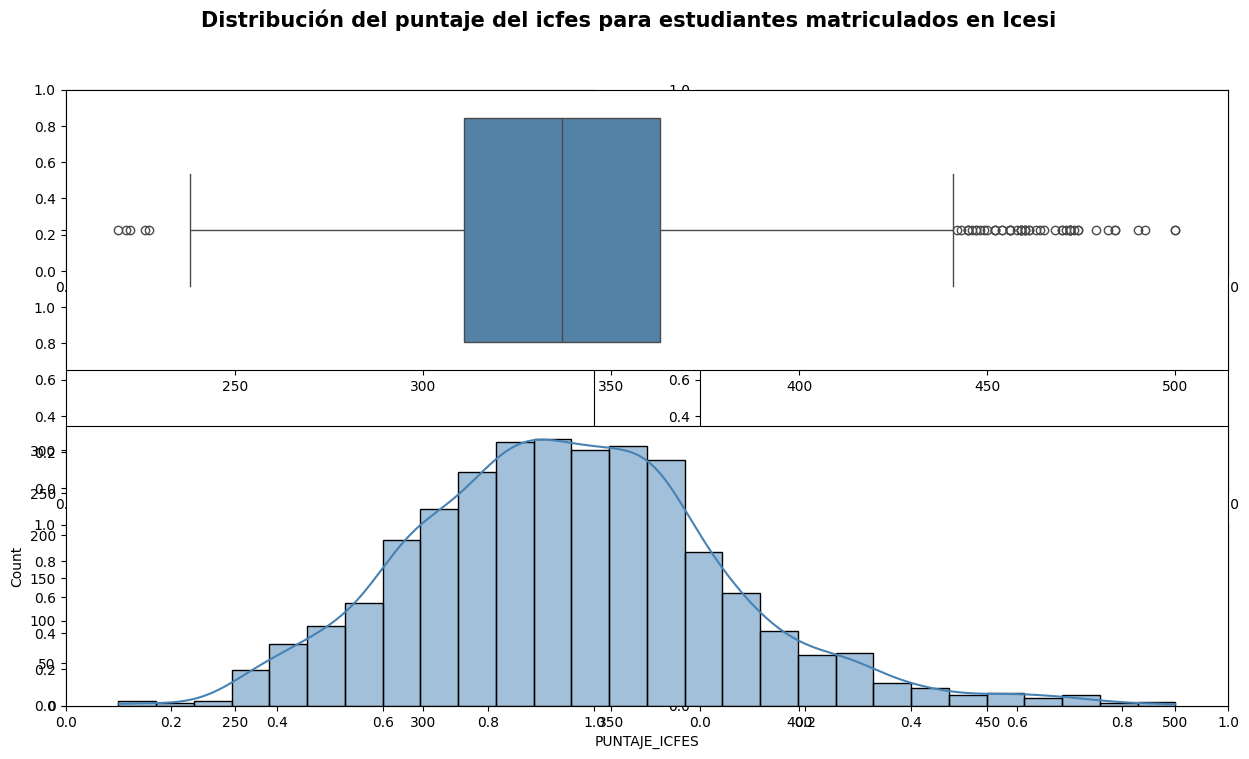

In [39]:
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(15, 8))
fig.suptitle("Distribución del puntaje del icfes para estudiantes matriculados en Icesi",fontsize=15, fontweight='bold')

plt.subplot(2,1,1)
ax=sns.boxplot(x=BASE_DESERCION_TEMPRANA['PUNTAJE_ICFES'],color="steelblue")
plt.xlabel(" ")

plt.subplot(2,1,2)
ax=sns.histplot(x=BASE_DESERCION_TEMPRANA['PUNTAJE_ICFES'],kde=True,color="steelblue",
                bins=round(1+3.322*np.log(len(BASE_DESERCION_TEMPRANA['PUNTAJE_ICFES']))))

In [40]:
def find_outliers_IQR(df):
    q1 = df.quantile(0.25)
    q3 = df.quantile(0.75)
    IQR = q3 - q1

    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR

    outliers = df[(df < lower_bound) | (df > upper_bound)]

    return outliers, lower_bound, upper_bound


outliers, lower, upper = find_outliers_IQR(BASE_DESERCION_TEMPRANA['PUNTAJE_ICFES'])

print(f"Número de outliers: {len(outliers)}")
print(f"Límite inferior: {lower}")
print(f"Límite superior: {upper}")

Número de outliers: 58
Límite inferior: 233.0
Límite superior: 441.0


Según lo evidenciado en la tabla anterior, se detecta la presencia de datos atípicos con limite inferior 233 y limite superior 441. Aunque estadísticamente estos serían posibles datos atípicos, es importante anotar que estos son valores admisibles, dado que, un estudiante podría tener estos puntajes. Por tal razón, estos datos no se eliminarán del dataset analizado.

#### Variable "EDAD"

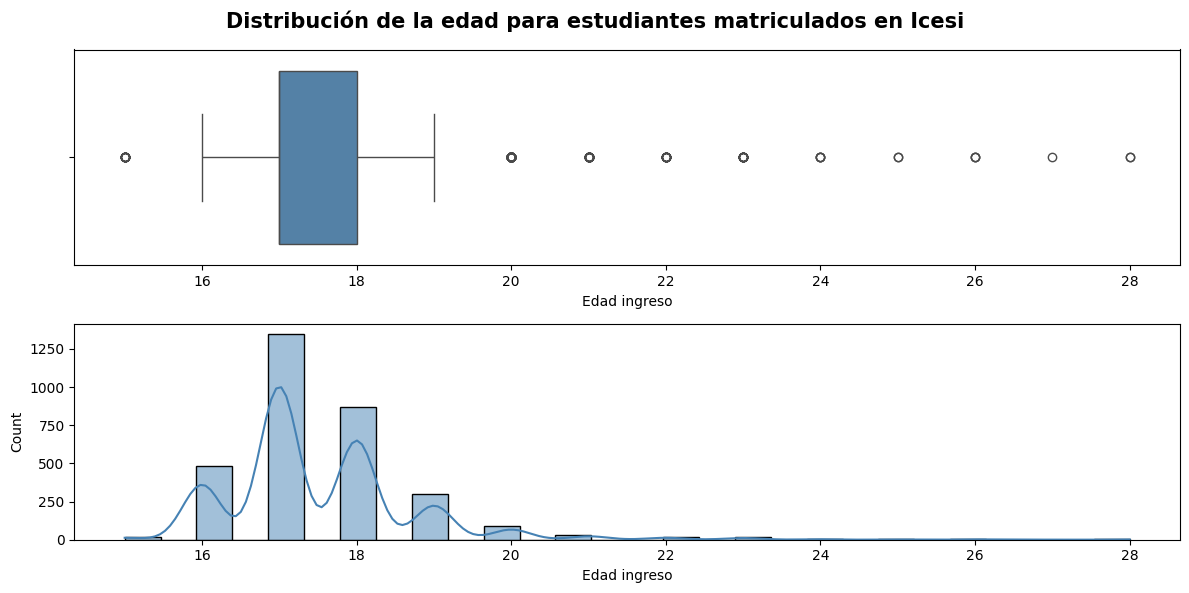

In [41]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12, 6))
fig.suptitle("Distribución de la edad para estudiantes matriculados en Icesi",
             fontsize=15, fontweight='bold')

# --- Boxplot ---
sns.boxplot(x=BASE_DESERCION_TEMPRANA['EDAD_INGRESO'], color="steelblue", ax=axs[0])
axs[0].set_xlabel("Edad ingreso")

# --- Histograma ---
sns.histplot(x=BASE_DESERCION_TEMPRANA['EDAD_INGRESO'],
             kde=True, color="steelblue",
             bins=round(1 + 3.322*np.log(len(BASE_DESERCION_TEMPRANA['EDAD_INGRESO']))),
             ax=axs[1])
axs[1].set_xlabel("Edad ingreso")

plt.tight_layout()
plt.show()


In [42]:
outliers, lower, upper = find_outliers_IQR(BASE_DESERCION_TEMPRANA['EDAD_INGRESO'])

print(f"Número de outliers: {len(outliers)}")
print(f"Límite inferior: {lower}")
print(f"Límite superior: {upper}")

Número de outliers: 180
Límite inferior: 15.5
Límite superior: 19.5


Se detecta la presencia de datos atípicos por debajo de 15.5 y por encima de 19.5. Aunque estadísticamente estos serían posibles datos atípicos, es importante anotar que estos son valores admisibles, pues en la Universidad no existe un máximo de edad fijado para entrar a la Universidad. Por tal razón, estos datos no se eliminarán del dataset analizado.

In [45]:
len(BASE_DESERCION_TEMPRANA)


3181

## 6. Análisis Univariado

### Puntaje ICFES

In [ ]:
BASE_DESERCION_TEMPRANA["PUNTAJE_ICFES"].describe()

count    3181.000000
mean      338.524363
std        41.072774
min       219.000000
25%       311.000000
50%       337.000000
75%       363.000000
max       500.000000
Name: PUNTAJE_ICFES, dtype: float64

In [ ]:
BASE_DESERCION_TEMPRANA["PUNTAJE_ICFES"].median()

np.float64(337.0)

En esta primera aproximación a la variable, es importante indicar que la media (338.5) es casi igual a la mediana (337), lo que anticipa la presencia de una **distribución simétrica**. El menor puntaje registrado es 219 mientras que el máximo es 500. Con los datos actuales se puede decir que **el 50% de los estudiantes incluidos en la muestra tienen puntajes entre 311 y 363**.

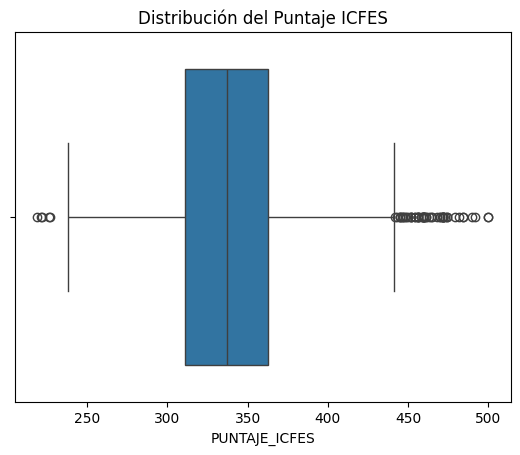

In [ ]:
# Boxplot
sns.boxplot(x=BASE_DESERCION_TEMPRANA["PUNTAJE_ICFES"])
plt.title("Distribución del Puntaje ICFES")
plt.show()

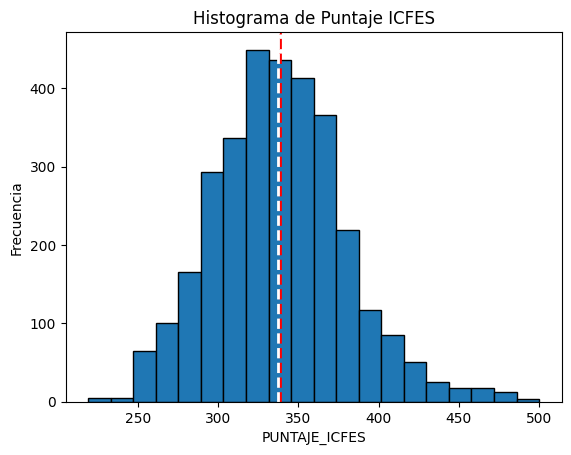

In [ ]:
#Histograma
plt.hist(BASE_DESERCION_TEMPRANA["PUNTAJE_ICFES"], bins=20, edgecolor="black")
plt.axvline(BASE_DESERCION_TEMPRANA['PUNTAJE_ICFES'].mean(), color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(BASE_DESERCION_TEMPRANA['PUNTAJE_ICFES'].median(), color='white', linestyle='dashed', linewidth=2, label='Mediana')
plt.xlabel("PUNTAJE_ICFES")
plt.ylabel("Frecuencia")
plt.title("Histograma de Puntaje ICFES")
plt.show()

### Estrato

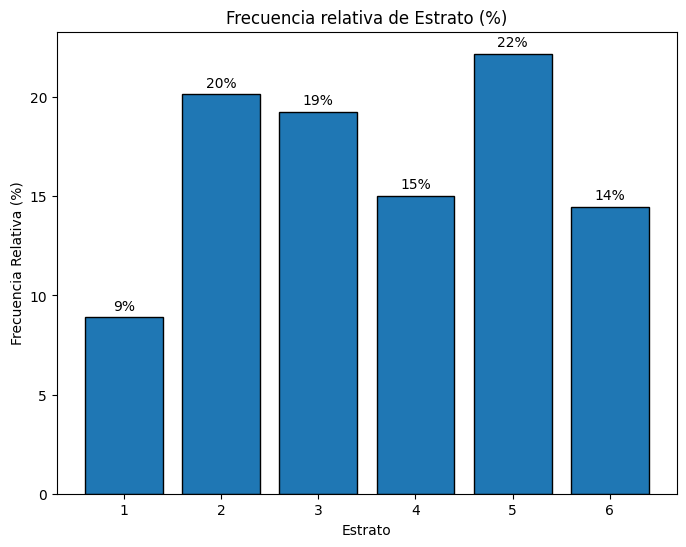

In [ ]:
# Construcción de la tabla
tabla_freq_estra = pd.crosstab(
    index=BASE_DESERCION_TEMPRANA["ESTRATO"],
    columns="count"
).reset_index()

tabla_freq_estra['Freq. Rel.'] = tabla_freq_estra['count'] / tabla_freq_estra['count'].sum()

# Gráfico de barras con frecuencias absolutas
fig, axs = plt.subplots(1, 1, figsize=(8,6))

bars = axs.bar(tabla_freq_estra["ESTRATO"], tabla_freq_estra["Freq. Rel."]*100, edgecolor="black" )

axs.set_title("Frecuencia relativa de Estrato (%)")
axs.set_xlabel("Estrato")
axs.set_ylabel("Frecuencia Relativa (%)")

# Etiquetas sobre las barras
axs.bar_label(
    bars,
    labels=[f"{val:.0f}%" for val in tabla_freq_estra["Freq. Rel."]*100],
    padding=3
)

plt.show()

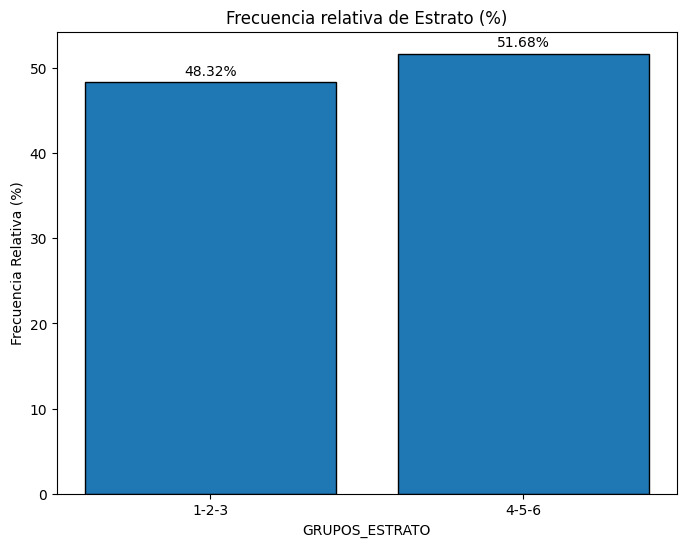

In [ ]:
# Construcción de la tabla
tabla_freq_estra1 = pd.crosstab(
    index=BASE_DESERCION_TEMPRANA["GRUPOS_ESTRATO"],
    columns="count"
).reset_index()

tabla_freq_estra1['Freq. Rel.'] = tabla_freq_estra1['count'] / tabla_freq_estra1['count'].sum()

# Gráfico de barras con frecuencias absolutas
fig, axs = plt.subplots(1, 1, figsize=(8,6))

bars = axs.bar(tabla_freq_estra1["GRUPOS_ESTRATO"], tabla_freq_estra1["Freq. Rel."]*100, edgecolor="black")

axs.set_title("Frecuencia relativa de Estrato (%)")
axs.set_xlabel("GRUPOS_ESTRATO")
axs.set_ylabel("Frecuencia Relativa (%)")

# Etiquetas sobre las barras
axs.bar_label(
    bars,
    labels=[f"{val:.2f}%" for val in tabla_freq_estra1["Freq. Rel."]*100],
    padding=3
)

plt.show()

El estrato más prominente en la muestra de estudiantes es el estrato 5, seguido por los estratos 2,3,4,6 y terminando con el 1. En términos generales, los estratos 4-5-6 son los más predominantes en la población estudiantil de la facultad de FNE.

### Edad

In [ ]:
BASE_DESERCION_TEMPRANA["EDAD_INGRESO"].describe()

count    3181.000000
mean       17.508645
std         1.247767
min        15.000000
25%        17.000000
50%        17.000000
75%        18.000000
max        28.000000
Name: EDAD_INGRESO, dtype: float64

El análisis general de la edad, nos indica un promedio de 17 años, adiconal que el 75% de los estudiantes al momento de ingresar contaban con 18 años. Tener presente que existen datos atipicos, sin embargo, como se aclaró en la parte outliers, está correcto dejarlos en el análisis, dado que la universidad no tiene un limite de edad para admisión.


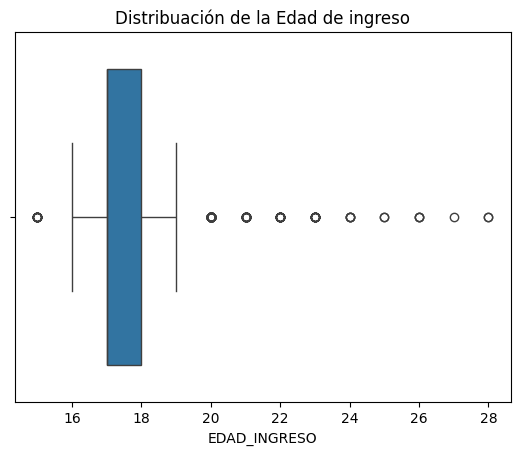

In [ ]:
# Boxplot
sns.boxplot(x=BASE_DESERCION_TEMPRANA["EDAD_INGRESO"])
plt.title("Distribuación de la Edad de ingreso")
plt.show()

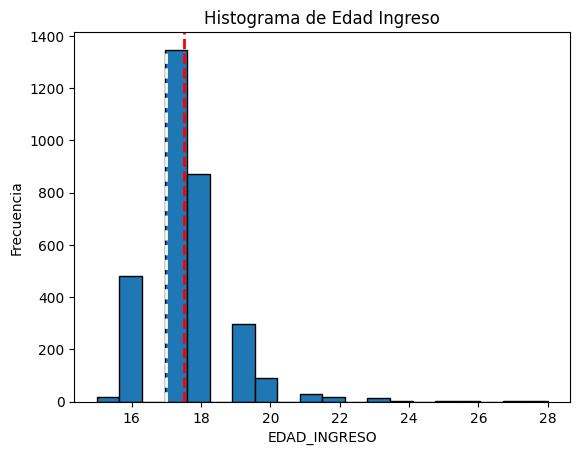

In [ ]:
#Histograma
plt.hist(BASE_DESERCION_TEMPRANA["EDAD_INGRESO"], bins=20, edgecolor="black")
plt.axvline(BASE_DESERCION_TEMPRANA['EDAD_INGRESO'].mean(), color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(BASE_DESERCION_TEMPRANA['EDAD_INGRESO'].median(), color='white', linestyle='dashed', linewidth=2, label='Mediana')
plt.xlabel("EDAD_INGRESO")
plt.ylabel("Frecuencia")
plt.title("Histograma de Edad Ingreso")
plt.show()

En la gráfica se **marca la media (rojo) y mediana (blanca)**, y se observa que la media es mayor que la mediana, lo que confirma un **sesgo positivo (distribución asimetrica a la derecha)** Poodemos evidenciar que los estudiantes en su mayoría tiene entre 15 a 18 años, con una cola larga a la derecha con estudiantes cuya edad es 20 años en adelante.



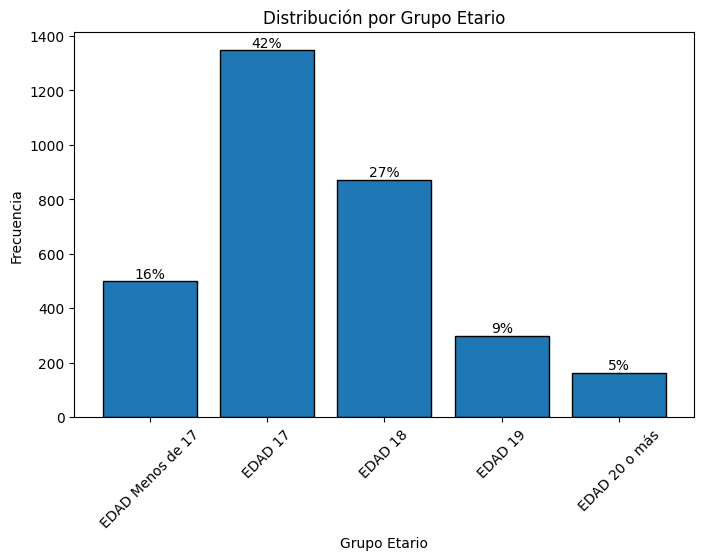

In [ ]:
orden = ["EDAD Menos de 17", "EDAD 17", "EDAD 18", "EDAD 19", "EDAD 20 o más"]

conteo = BASE_DESERCION_TEMPRANA['GRUPOS_ETARIOS'].value_counts().reindex(orden)

plt.figure(figsize=(8,5))
bars = plt.bar(conteo.index, conteo.values, edgecolor="black") # Store the bars

plt.title("Distribución por Grupo Etario")
plt.xlabel("Grupo Etario")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)

# Add percentage labels
total = conteo.sum()
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval/total:.0%}', va='bottom', ha='center')

plt.show()

**El 42% de los estudiantes pertenecen a la edad de 17 años**, seguido de un 27% que corresponden al grupo etario edad 18 años. Tal como se observaba con la distribución asimetrica, solo el 5% de los estudiantes tienen 20 o más años.

### Sexo

In [ ]:
# Frecuencia absoluta
print(BASE_DESERCION_TEMPRANA['SEXO'].value_counts())

# Frecuencia relativa (%)
print(BASE_DESERCION_TEMPRANA['SEXO'].value_counts(normalize=True) * 100)

SEXO
F    1690
M    1491
Name: count, dtype: int64
SEXO
F    53.127947
M    46.872053
Name: proportion, dtype: float64


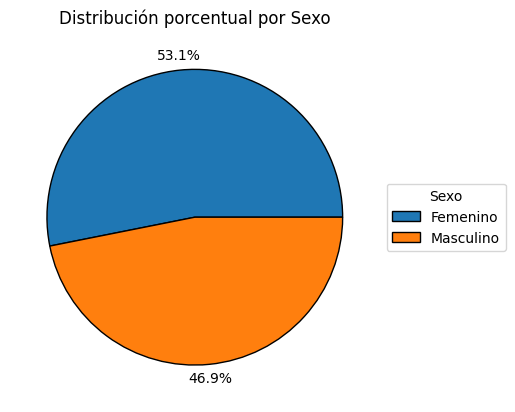

In [ ]:
conteo = BASE_DESERCION_TEMPRANA['SEXO'].value_counts()
etiquetas = conteo.index.map({'F': 'Femenino', 'M': 'Masculino'})

conteo.plot(
    kind='pie',
    autopct='%1.1f%%',
    textprops={'color': 'black'},
    pctdistance=1.1,
    labels=None,
    wedgeprops={'edgecolor': 'black'}  # ← aquí van los bordes
)

plt.title("Distribución porcentual por Sexo")
plt.ylabel("")
plt.legend(labels=etiquetas, title="Sexo", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.show()

En la base de datos de estudio hay un total de 1690 mujeres y 1491 hombres. Si lo llevamos a porcentaje, existe una proporción de mujeres (53%) levemente superios que la de hombres (47%)

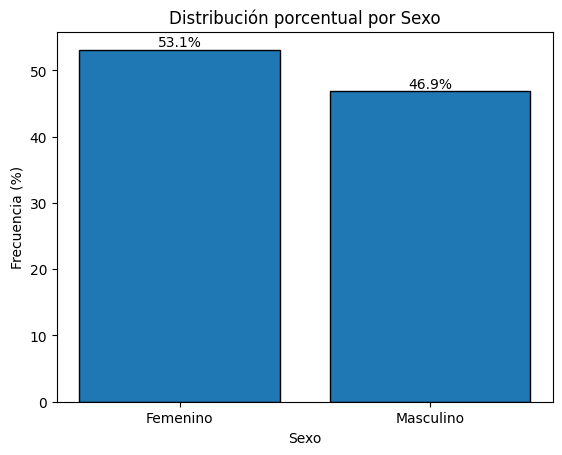

In [ ]:
conteo = BASE_DESERCION_TEMPRANA['SEXO'].value_counts(normalize=True) * 100

# Create the bar plot
bars = plt.bar(conteo.index, conteo.values, edgecolor='black') # Changed colors

plt.title("Distribución porcentual por Sexo")
plt.xlabel("Sexo")
plt.ylabel("Frecuencia (%)") # Changed y-axis label
plt.xticks(ticks=[0, 1], labels=['Femenino', 'Masculino'], rotation=0) # Changed x-axis labels

# Add data labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.1f}%', va='bottom', ha='center') # Changed data labels to show percentages

plt.show()

### Estudiantes Ser Pilo Paga

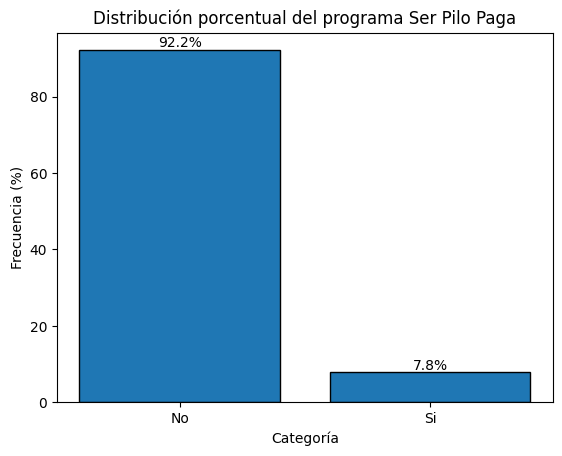

In [ ]:
conteo = BASE_DESERCION_TEMPRANA['ES_PILO'].value_counts(normalize=True) * 100

bars = plt.bar(conteo.index, conteo.values, edgecolor='black')
plt.title("Distribución porcentual del programa Ser Pilo Paga") # Updated title
plt.xlabel("Categoría")
plt.ylabel("Frecuencia (%)") # Updated y-axis label
plt.xticks(ticks=[0, 1], labels=['No', 'Si'], rotation=0)

# Add data labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.1f}%', va='bottom', ha='center') # Updated data labels to show percentages

plt.show()

El 7,8% de estudiantes pertenece al programa Pilo en la facultad de Negocios.

### Naturaleza del colegio

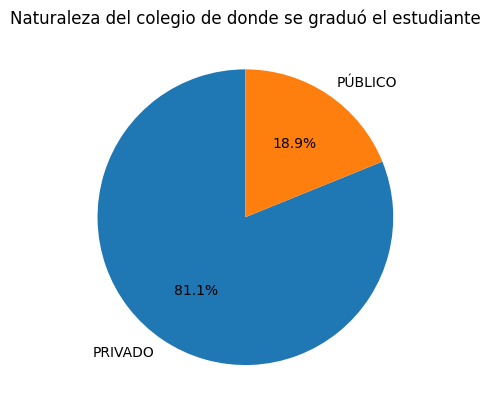

In [ ]:
tabla_freq=(pd.crosstab(index=BASE_DESERCION_TEMPRANA["NATURALEZA_COLEGIO"],columns="count")).reset_index()
tabla_freq['Freq. Rel.']=tabla_freq['count']/sum(tabla_freq['count'])
tabla_freq.rename(columns={'count':'Freq. Abs.'},inplace=True)
tabla_freq=tabla_freq.sort_values(by='Freq. Abs.',ascending=False).reset_index(drop=True)
tabla_freq

plt.pie(tabla_freq["Freq. Rel."], labels=tabla_freq["NATURALEZA_COLEGIO"],autopct='%1.1f%%',startangle=90)
plt.title("Naturaleza del colegio de donde se graduó el estudiante")
plt.show()

A través del gráfico anterior es posible ver que la mayoría de los estudiantes incluidos en la muestra (81%) vienen de colegios privados, mientras que el 19% de colegios públicos.

### Ciudad de procedencia

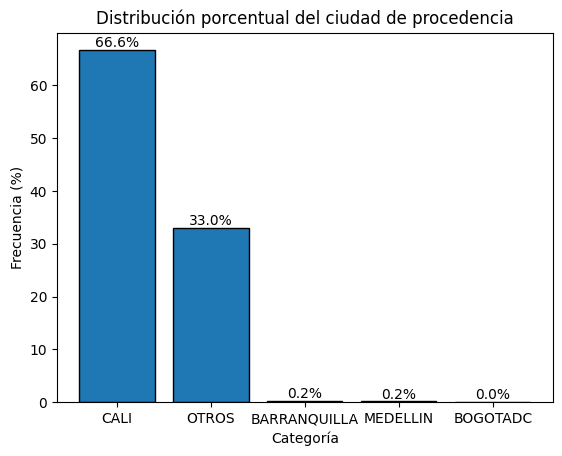

In [ ]:
conteo = BASE_DESERCION_TEMPRANA['CIUDAD_PRINCIPAL'].value_counts(normalize=True) * 100

bars = plt.bar(conteo.index, conteo.values, edgecolor='black')
plt.title("Distribución porcentual del ciudad de procedencia") # Updated title
plt.xlabel("Categoría")
plt.ylabel("Frecuencia (%)") # Updated y-axis label

# Add data labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.1f}%', va='bottom', ha='center') # Updated data labels to show percentages

plt.show()

Como se puede apreciar en el gráfico anterior, la mayoría de los estudiantes incluidos en la muestra (67%) vienen de colegios que están en la ciudad de CALI, el 33% viene de otras ciudades que no son ciudades principales, y un minoria vienen de ciudades principales como BARRANQUILLA, MEDELLIN Y BOGOTA.

### Motivo de retiro

In [ ]:
tabla_freq=(pd.crosstab(index=BASE_DESERCION_TEMPRANA["EVENTO_RETIRO"],columns="count")).reset_index()
tabla_freq['Freq. Rel.']=tabla_freq['count']/sum(tabla_freq['count'])
tabla_freq.rename(columns={'count':'Freq. Abs.'},inplace=True)
tabla_freq=tabla_freq.sort_values(by='Freq. Abs.',ascending=False).reset_index(drop=True)
tabla_freq

col_0,EVENTO_RETIRO,Freq. Abs.,Freq. Rel.
0,Retiro Bajo R. Académico (BR),377,0.368885
1,Retiro No Utilización De Cupo,323,0.316047
2,Retiro Por Reserva De Cupo,166,0.162427
3,Retiro por motivos personales,36,0.035225
4,Retiro por cambio de Universid,26,0.025440
5,Retiro Por Motivos De Salud,23,0.022505
6,Retiro Por Motivos Económicos,14,0.013699
7,Retiro Por Cambio Ciudad Res.,12,0.011742
8,Retiro Por Fin de Curso Libre,8,0.007828
9,Retiro Por Motivos De Trabajo,8,0.007828


Al revisar los motivos de retiro, se encuentra que el motivo más frecuencia es el retiro por bajo rendimiento académico, seguido por el retiro por no utilización de cupo y reserva de cupo. Históricamente, la mayoría de estudiantes en la Universidad Icesi se retiran por bajo rendimiento académico.

##  Análisis Bivariado

### Retiro temprano vs Sexo

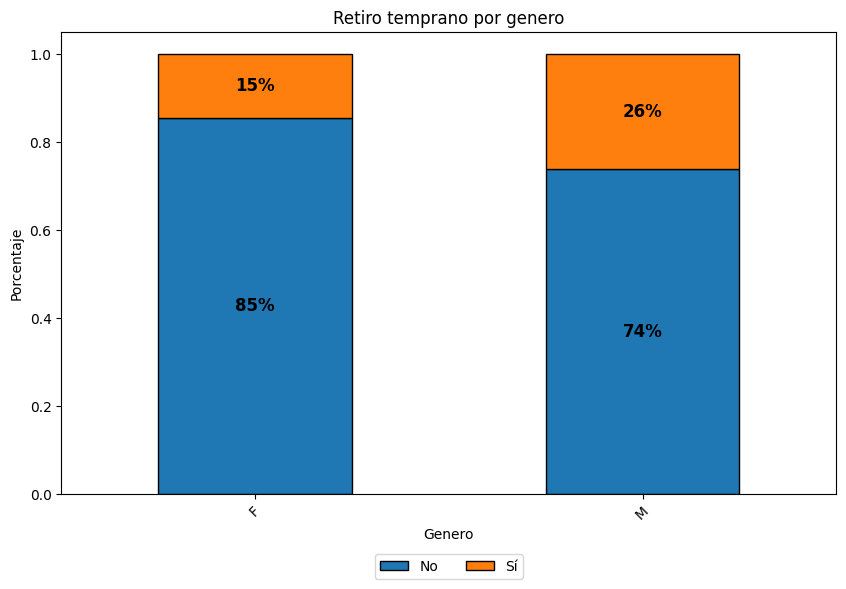

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(10, 6))

# Group the dataframe by the two variables and count the values
grouped = BASE_DESERCION_TEMPRANA.groupby(['SEXO', 'RETIRO']).size().unstack()

# Normalize the data by converting the counts to percentages
grouped = grouped.div(grouped.sum(axis=1), axis=0)



# Create a stacked bar graph
ax = grouped.plot(kind='bar', stacked=True, ax=axs, edgecolor='black')

# Set the axis labels and title
ax.set_xlabel("Genero")
ax.set_ylabel('Porcentaje')
ax.set_title('Retiro temprano por genero')
plt.xticks(rotation=45)

# Add labels to each bar in the stacked bar graph
for container in ax.containers:
    ax.bar_label(container, labels=[f'{val:.0%}' if val > 0 else '' for val in container.datavalues], label_type='center',fontweight='bold',fontsize=12)

# Move the legend to the lower center
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(grouped.columns))

# Display the graph
plt.show()

In [ ]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(pd.crosstab(BASE_DESERCION_TEMPRANA['SEXO'], BASE_DESERCION_TEMPRANA['RETIRO']))
print("Chi2 =", chi2, ", p =", p)

Chi2 = 65.85471946935898 , p = 4.854166032350581e-16


In [ ]:
proporcion = pd.crosstab(BASE_DESERCION_TEMPRANA['SEXO'], BASE_DESERCION_TEMPRANA['RETIRO'], normalize='index')
print(proporcion)

RETIRO        No        Sí
SEXO                      
F       0.853846  0.146154
M       0.737760  0.262240


Al graficar se identifica que el **15% de las mujeres** se retiran en los primeros cuatro semestres vs una deserción temprana en **hombres del 26%**. Al aplicar una prueba Chi-cuadrado, para validar si la variable sexo es significativa, identificamos un valor p <0,05; por lo que rechazamos H0, y podemos concluir que **si existe una relación estadisticamente significativa entre el sexo y la deserción temprana**.

### Retiro temprano vs Edad

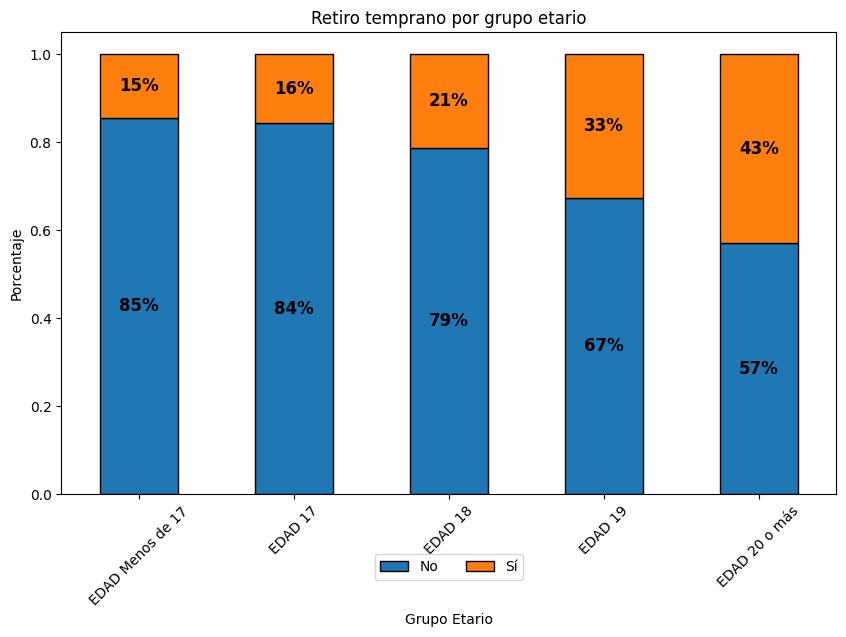

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(10, 6))

# Group the dataframe by the two variables and count the values
grouped = BASE_DESERCION_TEMPRANA.groupby(['GRUPOS_ETARIOS', 'RETIRO']).size().unstack()

# Normalize the data by converting the counts to percentages
grouped = grouped.div(grouped.sum(axis=1), axis=0)

# Reindex to maintain the desired order
orden = ["EDAD Menos de 17", "EDAD 17", "EDAD 18", "EDAD 19", "EDAD 20 o más"]
grouped = grouped.reindex(orden)

# Create a stacked bar graph
ax = grouped.plot(kind='bar', stacked=True, ax=axs, edgecolor='black')

# Set the axis labels and title
ax.set_xlabel("Grupo Etario")
ax.set_ylabel('Porcentaje')
ax.set_title('Retiro temprano por grupo etario')
plt.xticks(rotation=45)

# Add labels to each bar in the stacked bar graph
for container in ax.containers:
    ax.bar_label(container, labels=[f'{val:.0%}' if val > 0 else '' for val in container.datavalues], label_type='center',fontweight='bold',fontsize=12)

# Move the legend to the lower center
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(grouped.columns))

# Display the graph
plt.show()

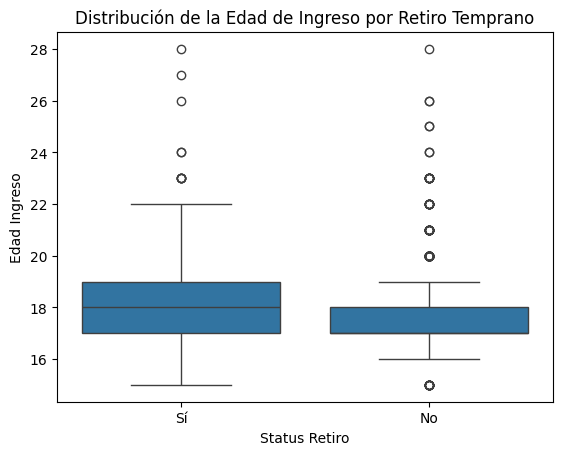

In [ ]:
sns.boxplot(x="RETIRO", y="EDAD_INGRESO", data=BASE_DESERCION_TEMPRANA)
plt.xlabel("Status Retiro")
plt.ylabel("Edad Ingreso")
plt.title("Distribución de la Edad de Ingreso por Retiro Temprano")
plt.show()

El boxplot sugiere que ingresar a la universidad en edades superiores a la media típica (17–18 años) podría estar asociado con una mayor probabilidad de retiro temprano.

La relación no es determinista (también hay jóvenes que se retiran), pero sí muestra una tendencia de mayor vulnerabilidad en estudiantes de ingreso tardío

### Retiro temprano vs Ser pilo paga

In [ ]:
BASE_DESERCION_TEMPRANA['ES_PILO'].value_counts()

ES_PILO
N    2932
S     249
Name: count, dtype: int64

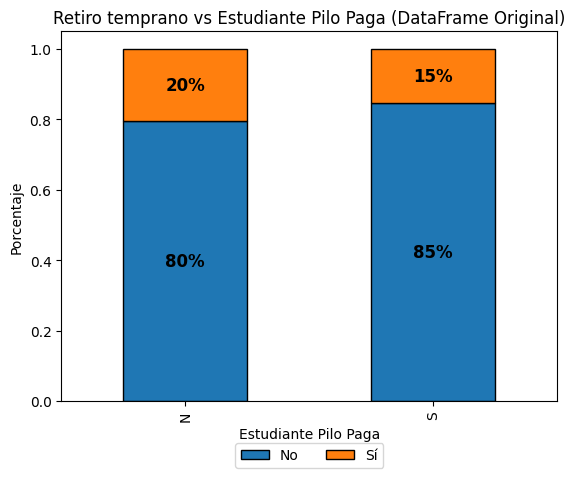

In [ ]:
# Perform bivariate analysis between 'RETIRO' and 'ES_PILO' using df_FNE
grouped_fne = BASE_DESERCION_TEMPRANA.groupby(['ES_PILO', 'RETIRO']).size().unstack()

# Normalize the data by converting the counts to percentages
grouped_fne = grouped_fne.div(grouped_fne.sum(axis=1), axis=0)

# Create a stacked bar graph
ax = grouped_fne.plot(kind='bar', stacked=True, edgecolor='black')

# Set the axis labels and title
ax.set_xlabel("Estudiante Pilo Paga")
ax.set_ylabel('Porcentaje')
ax.set_title('Retiro temprano vs Estudiante Pilo Paga (DataFrame Original)')

# Add labels to each bar in the stacked bar graph
for container in ax.containers:
    ax.bar_label(container, labels=[f'{val:.0%}' if val > 0 else '' for val in container.datavalues], label_type='center', fontweight='bold', fontsize=12)

# Move the legend to the lower center
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(grouped_fne.columns))

# Display the graph
plt.show()

In [ ]:
# Tabla de contingencia
tabla = pd.crosstab(BASE_DESERCION_TEMPRANA['ES_PILO'], BASE_DESERCION_TEMPRANA['RETIRO'])
print("Tabla de contingencia:\n", tabla)

# Chi-cuadrado
chi2, p, dof, expected = chi2_contingency(tabla)
print("\nChi2 =", chi2, " p =", p, " grados de libertad =", dof)

# Cálculo del V de Cramer
n = tabla.sum().sum()   # total de observaciones
min_dim = min(tabla.shape) - 1
v_cramer = np.sqrt((chi2 / n) / min_dim)
print("V de Cramer =", v_cramer)

Tabla de contingencia:
 RETIRO     No   Sí
ES_PILO           
N        2332  600
S         211   38

Chi2 = 3.556976250152617  p = 0.05929566023326718  grados de libertad = 1
V de Cramer = 0.03343941323002513


Se realiza prueba de chi cuadrado, dado que el valor p>0,05 la pertenencia al programa Pilo no parece ser un factor relevante en la probabilidad de retiro en esta muestra.

### Retiro temprano vs. Puntaje Icfes

In [ ]:
tabla_cont=BASE_DESERCION_TEMPRANA.groupby(by=["RETIRO"])["PUNTAJE_ICFES"].describe().sort_values(by='50%', ascending=False)
tabla_cont

,count,mean,std,min,25%,50%,75%,max
RETIRO,,,,,,,,
No,2543.0,340.480535,39.860905,219.0,314.0,339.0,364.0,492.0
Sí,638.0,330.727273,44.775606,222.0,298.0,327.0,356.0,500.0


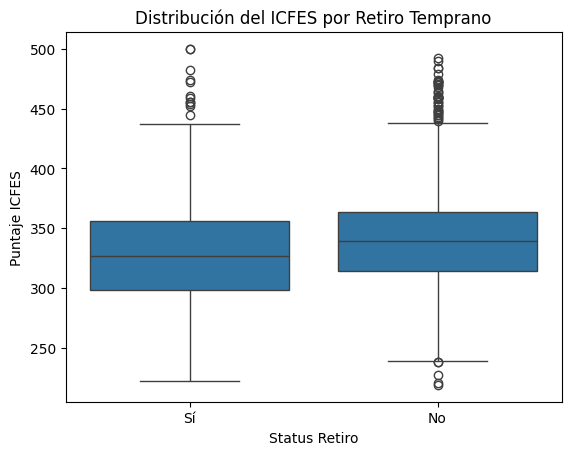

In [ ]:
sns.boxplot(x="RETIRO", y="PUNTAJE_ICFES", data=BASE_DESERCION_TEMPRANA )
plt.xlabel("Status Retiro")
plt.ylabel("Puntaje ICFES")
plt.title("Distribución del ICFES por Retiro Temprano")
plt.show()

La gráfica sugiere que los estudiantes con puntajes ICFES más bajos tienden a retirarse con mayor frecuencia, sin embargo hay retirados que tienen puntajes muy altos.

### Retiro temprano vs. Estrato

C:\Users\1116282909\AppData\Local\Temp\ipykernel_28980\3376409492.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = BASE_DESERCION_TEMPRANA.groupby(['ESTRATO', 'RETIRO']).size().unstack()


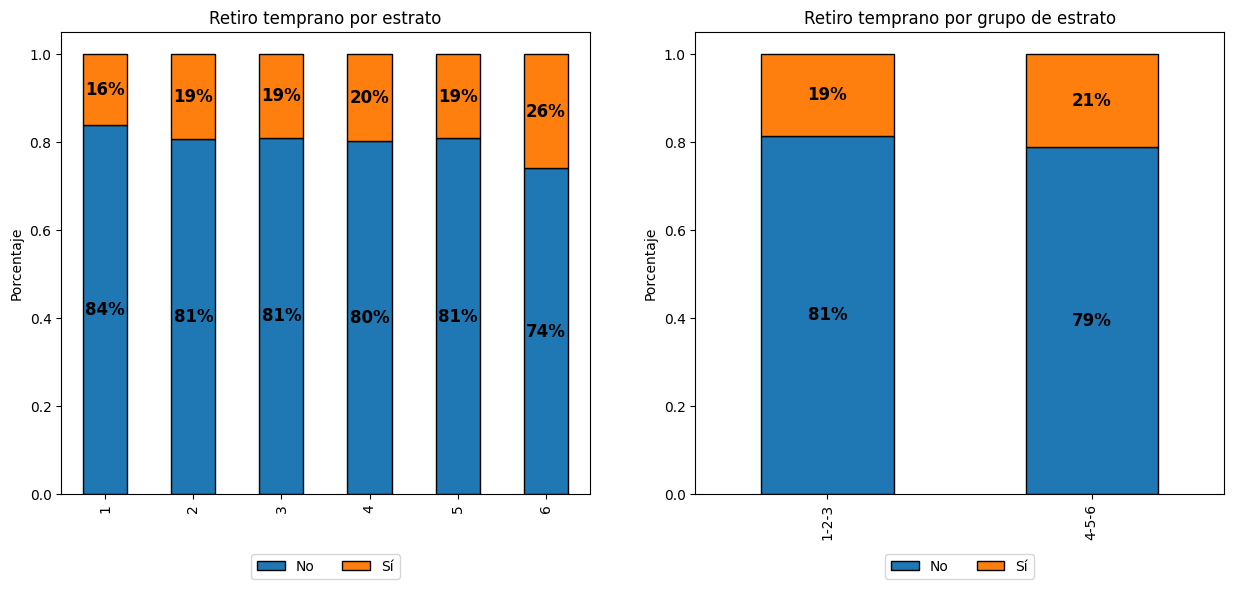

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

grouped = BASE_DESERCION_TEMPRANA.groupby(['ESTRATO', 'RETIRO']).size().unstack()
grouped = grouped.div(grouped.sum(axis=1), axis=0)
ax = grouped.plot(kind='bar', stacked=True, ax=axs[0], edgecolor='black')
ax.set_xlabel('')
ax.set_ylabel('Porcentaje')
ax.set_title('Retiro temprano por estrato')
for container in ax.containers:
    ax.bar_label(container, labels=[f'{val:.0%}' if val > 0 else '' for val in container.datavalues], label_type='center',fontweight='bold',fontsize=12)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(grouped.columns))

grouped = BASE_DESERCION_TEMPRANA.groupby(['GRUPOS_ESTRATO', 'RETIRO']).size().unstack()
grouped = grouped.div(grouped.sum(axis=1), axis=0)
ax = grouped.plot(kind='bar', stacked=True, ax=axs[1], edgecolor='black')
ax.set_xlabel('')
ax.set_ylabel('Porcentaje')
ax.set_title('Retiro temprano por grupo de estrato')
for container in ax.containers:
    ax.bar_label(container, labels=[f'{val:.0%}' if val > 0 else '' for val in container.datavalues], label_type='center', fontweight='bold',fontsize=12)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(grouped.columns))

plt.show()

Se puede evidenciar que a medida que sube el estrato, mayor es la proporción de los estudiante que se retiran tempranamente. Así mismo, este comprotamiento se puede confirmar en el grafico de los estrato agrupados por 1-2-3 y 4-5-6. Aunque, la diferencia es minima se mantiene la tendencia de que los estratos mayores tienen una mayor proporcion de retirados en los primeros semestres.


### Retiro temprano vs. Naturaleza del colegio

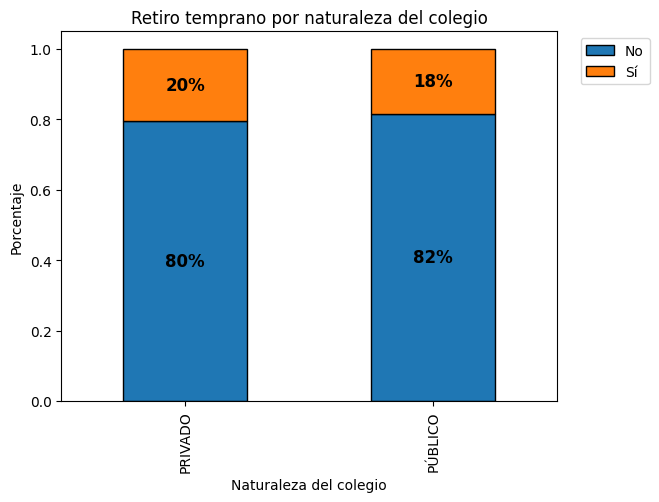

In [ ]:
# Group the dataframe by the two variables and count the values
grouped = BASE_DESERCION_TEMPRANA.groupby(['NATURALEZA_COLEGIO', 'RETIRO']).size().unstack()

# Normalize the data by converting the counts to percentages
grouped = grouped.div(grouped.sum(axis=1), axis=0)

# Create a stacked bar graph
ax = grouped.plot(kind='bar', stacked=True, edgecolor='black')

# Set the axis labels and title
ax.set_xlabel("Naturaleza del colegio")
ax.set_ylabel('Porcentaje')
ax.set_title('Retiro temprano por naturaleza del colegio')

# Add labels to each bar in the stacked bar graph
for container in ax.containers:
    ax.bar_label(container, labels=[f'{val:.0%}' if val > 0 else '' for val in container.datavalues], label_type='center',fontweight='bold',fontsize=12)

# Move the legend to the top right of the graph
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1))

# Display the graph
plt.show()

Los estudiantes provenientes de colegios privados tienen una tasa de retiro temprano ligeramente mayor (20%) en comparación con los de colegios públicos (18%).

In [ ]:
tabla_contingencia = pd.crosstab(index=BASE_DESERCION_TEMPRANA['NATURALEZA_COLEGIO'], columns=BASE_DESERCION_TEMPRANA['GRUPOS_ESTRATO'])
tabla_contingencia

GRUPOS_ESTRATO,1-2-3,4-5-6
NATURALEZA_COLEGIO,,
PRIVADO,975,1606
PÚBLICO,562,38


La gráfica anterior muestra que los estudiantes que se matricularon en Icesi y que estudiaron en colegios públicos se retiran en una menor medida que los estudiantes que estudiaron en colegios privados. Este resultado pudiera estar influenciado por el hecho de que la mayoría de estudiantes matriculados de colegios públicos pertenecen a estratos medio-bajos, así como se puede ver en la anterior tabla de contingencia. Y, como ya se veía con anterioridad, los estratos medio-bajos reportan —al menos para la muestra analizada— una tasa de deserción temprana menor.

### Retiro temprano vs. Ciudad de procedencia

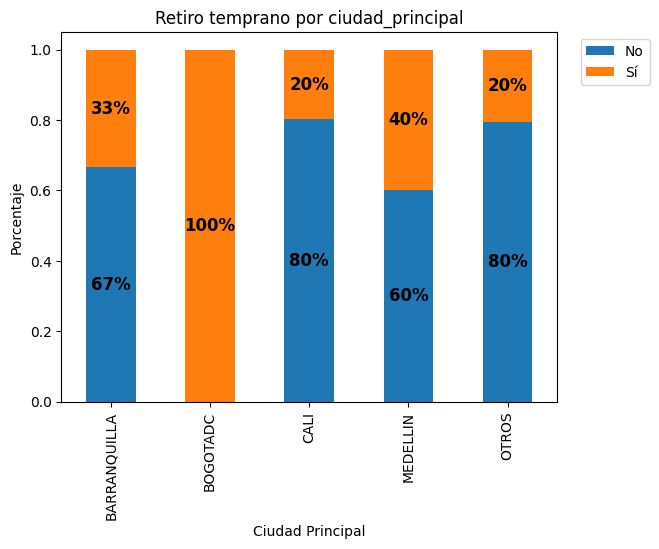

In [ ]:
# Group the dataframe by the two variables and count the values
grouped = BASE_DESERCION_TEMPRANA.groupby(['CIUDAD_PRINCIPAL', 'RETIRO']).size().unstack()

# Normalize the data by converting the counts to percentages
grouped = grouped.div(grouped.sum(axis=1), axis=0)

# Create a stacked bar graph
ax = grouped.plot(kind='bar', stacked=True)

# Set the axis labels and title
ax.set_xlabel("Ciudad Principal")
ax.set_ylabel('Porcentaje')
ax.set_title('Retiro temprano por ciudad_principal')

# Add labels to each bar in the stacked bar graph
for container in ax.containers:
    ax.bar_label(container, labels=[f'{val:.0%}' if val > 0 else '' for val in container.datavalues], label_type='center',fontweight='bold',fontsize=12)

# Move the legend to the top right of the graph
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1))

# Display the graph
plt.show()

In [ ]:
BASE_DESERCION_TEMPRANA["CIUDAD_PRINCIPAL"].value_counts()

CIUDAD_PRINCIPAL
CALI            2120
OTROS           1049
BARRANQUILLA       6
MEDELLIN           5
BOGOTADC           1
Name: count, dtype: int64

BARRANQUILLA y MEDELLIN presentan tasas de deserción temprana superiores a las de CALI y OTROS municipios, probablemente esos otros municipios pertenezcan al departamento del Valle del cauca o departamentos cercanos por lo que tienen mayor permanencia en la Universidad. EL caso de BOGOTA, presenta 100% de retiro temprano, debido que en la muestra solo hay una persona y efectivamente esa persona se retiro dentro de los 4 primeros semestres

## 8. Respuesta a la pregunta SMART

La pregunta de negocio que guió nuestro análisis fue la siguiente: **¿Cuáles son los factores que más influyen en la deserción temprana (semestres 1 a 4) de los estudiantes de la facultad de Negocios y Economía de la Universidad Icesi?**

 Al finalizar el análisis exploratorio de datos fue posible descubrir las variables que pueden influir en una baja/media/alta magnitud en la probabilidad de deserción. Estas variables son:

- El **puntaje del estudiantes en las pruebas Saber 11**.
- La **edad del estudiante**.
- El **sexo** del estudiante.
- Si el colegio en el que el estudiante se graduó es **público o privado**.
- El **estrato socioeconómico** al que pertenece el estudiante al momento de matricularse.


## 9. Regresión Logística

Se escogen las posibles variables que irán al modelo

In [ ]:
BASE_DESERCION_TEMPRANA = BASE_DESERCION_TEMPRANA[["ES_PILO","SEXO","PUNTAJE_ICFES","ESTRATO","NATURALEZA_COLEGIO","EDAD_INGRESO","CIUDAD_PRINCIPAL","RETIRO"]]

In [ ]:
BASE_DESERCION_TEMPRANA

,ES_PILO,SEXO,PUNTAJE_ICFES,ESTRATO,NATURALEZA_COLEGIO,EDAD_INGRESO,CIUDAD_PRINCIPAL,RETIRO
0,N,F,332.0,3,PRIVADO,18,CALI,Sí
1,N,M,318.0,4,PRIVADO,18,CALI,Sí
2,N,F,343.0,3,PRIVADO,19,CALI,Sí
3,N,F,308.0,4,PRIVADO,17,CALI,Sí
4,N,F,370.0,2,PRIVADO,16,CALI,Sí
...,...,...,...,...,...,...,...,...
3176,N,M,405.0,5,PRIVADO,18,CALI,No
3177,N,M,330.0,5,PRIVADO,16,CALI,No
3178,N,M,410.0,5,PRIVADO,17,CALI,No
3179,N,F,330.0,6,PRIVADO,18,CALI,No


Se realiza una copia de la base de datos para transformar las variables categóricas en binarias y posteriormente calcular la correlación con la variable objetivo.

In [ ]:
eda_df = BASE_DESERCION_TEMPRANA.copy()

In [ ]:
le = LabelEncoder()
eda_df['SEXO'] = le.fit_transform(eda_df['SEXO'])
eda_df['RETIRO'] = le.fit_transform(eda_df['RETIRO'])
eda_df['NATURALEZA_COLEGIO'] = le.fit_transform(eda_df['NATURALEZA_COLEGIO'])
eda_df['ES_PILO'] = le.fit_transform(eda_df['ES_PILO'])
eda_df["CIUDAD_PRINCIPAL"] = np.where(eda_df["CIUDAD_PRINCIPAL"].isin(CIUDADES_PRINCIPALES),1,0)

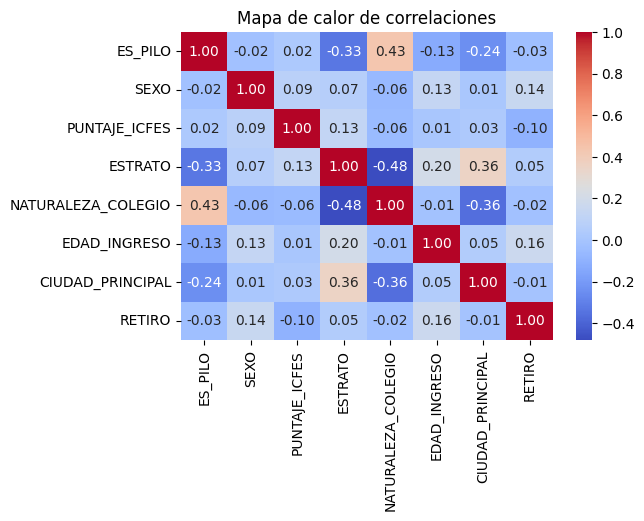

In [ ]:
corr = eda_df.corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de calor de correlaciones")
plt.show()

Se observa que ninguna variable tiene una correlación fuerte para determinar el comportamiento del retiro temprano mediante un modelo de regresión. Se pueden fortalecer los datos haciendo ingenieria de variables e incluyendo variables como promedio del estudiante, materias matriculadas o creditos por semestre. Sin embargo, para efectos del ejercicio, haremos el modelo de regresión con las variables SEXO, PUNTAJE ICFES y EDAD INGRESO.

Se separan variables categóricas y númericas

In [ ]:
num_cols = ["PUNTAJE_ICFES", "EDAD_INGRESO"]
cat_cols = ["SEXO"]

Se separan variables independientes y la variable dependiente se convierte en binaria.

In [ ]:
X = BASE_DESERCION_TEMPRANA[num_cols + cat_cols]
y = BASE_DESERCION_TEMPRANA["RETIRO"].map({"No":0,"Sí":1})

Creamos pipeline de preprocesamiento, en donde las variables categóricas se escalan y a las variables categóricas se les aplica One Hot Encoder. Posteriormente, se entrena el modelo de regresión.

In [ ]:
# --- Preprocesamiento ---
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ]
)

In [ ]:
# --- Pipeline ---
pipeline = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", LogisticRegression(class_weight="balanced", solver="liblinear", max_iter=2000))
])

Se dividen los datos en 70% entrenamiento y 30% prueba, dado que las dos clases estan desbalanceadas se usa Stratify para mantener la proporción de retirados y no retirados en el conjunto de Train y de Test. Luego, se entrena le pipeline.

In [ ]:
# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [ ]:
# --- Entrenar ---
pipeline.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Se hacen las predicciones del modelo

In [ ]:
# --- Predicciones ---
y_proba = pipeline.predict_proba(X_test)[:,1]
y_pred = (y_proba >= 0.5).astype(int)

Evaluación del modelo y métricas

In [ ]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

# --- Ver features transformados ---
ohe = pipeline.named_steps["prep"].named_transformers_["cat"]
feature_names = np.r_[num_cols, ohe.get_feature_names_out(cat_cols)]
print(feature_names)

[[476 287]
 [ 71 121]]
              precision    recall  f1-score   support

           0     0.8702    0.6239    0.7267       763
           1     0.2966    0.6302    0.4033       192

    accuracy                         0.6251       955
   macro avg     0.5834    0.6270    0.5650       955
weighted avg     0.7549    0.6251    0.6617       955

ROC AUC: 0.6755099115334208
['PUNTAJE_ICFES' 'EDAD_INGRESO' 'SEXO_M']


el modelo logra capturar cierta señal en los datos (ROC AUC = 0.67), pero tiene muchos falsos positivos (predice retiro cuando no lo hay). Le cuesta precisar quién realmente se retira (precision baja = 30%). Sin embargo, sí logra recuperar alrededor de la mitad de los casos reales de retiro (recall 63%).

Se busca umbral optimo y se vuelven a calcular las métricas.

In [ ]:
# Probabilidades del conjunto de test
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Buscar umbral óptimo según F1
prec, rec, thr = precision_recall_curve(y_test, y_proba)
thr_full = np.r_[0.0, thr, 1.0]
f1s = [f1_score(y_test, (y_proba >= t).astype(int)) for t in thr_full]

t_best = thr_full[np.argmax(f1s)]
print(f"Umbral óptimo (max F1): {t_best:.4f}")

# Recalcular predicciones con ese umbral
y_opt = (y_proba >= t_best).astype(int)

# Evaluación con umbral óptimo
print("Matriz de confusión:\n", confusion_matrix(y_test, y_opt))
print("Precision:", precision_score(y_test, y_opt))
print("Recall:", recall_score(y_test, y_opt))
print("F1:", f1_score(y_test, y_opt))

Umbral óptimo (max F1): 0.5562
Matriz de confusión:
 [[590 173]
 [ 93  99]]
Precision: 0.3639705882352941
Recall: 0.515625
F1: 0.4267241379310345


El cambio de umbral mejora la precisión sacrificando algo de recall, pero para mejorar realmente el rendimiento, necesitas más variables explicativas o modelos más complejos